In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
X=dataset.iloc[:, [3,4]]

In [5]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


Text(0.5, 1.0, 'Similarity Matrix')

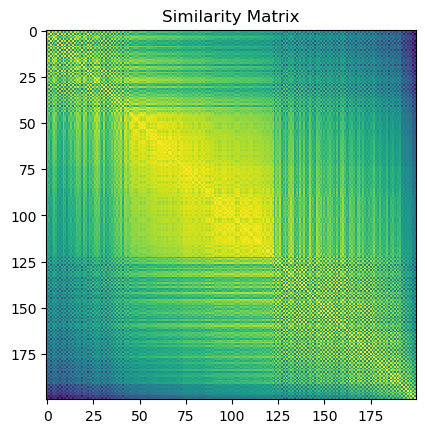

In [6]:
from sklearn.metrics.pairwise import euclidean_distances

similarity = -euclidean_distances(X)

plt.imshow(similarity)
plt.title("Similarity Matrix")
#plt.xlabel("Data Points")
#plt.ylabel('Euclidean distances')
#plt.colorbar()
#plt.show()

In [7]:
similarity

array([[  -0.        ,  -42.        ,  -33.01514804, ..., -116.38728453,
        -123.79418403, -129.69194269],
       [ -42.        ,   -0.        ,  -75.00666637, ..., -111.22050171,
        -137.3062271 , -122.01639234],
       [ -33.01514804,  -75.00666637,   -0.        , ..., -129.32130528,
        -121.59358536, -143.42245291],
       ...,
       [-116.38728453, -111.22050171, -129.32130528, ...,   -0.        ,
         -57.07013229,  -14.2126704 ],
       [-123.79418403, -137.3062271 , -121.59358536, ...,  -57.07013229,
          -0.        ,  -65.        ],
       [-129.69194269, -122.01639234, -143.42245291, ...,  -14.2126704 ,
         -65.        ,   -0.        ]])

In [8]:
from sklearn.cluster import AffinityPropagation

In [14]:
clusmodel=model = AffinityPropagation(damping=0.7,
    max_iter=200,
    convergence_iter=15,
    preference=-10000,  
    affinity='euclidean'
)

label=clusmodel.fit_predict(X)

In [15]:
Supervised=pd.DataFrame(dataset)

In [16]:
Supervised['cluster_group']=label

In [17]:
Supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,4
196,197,Female,45,126,28,3
197,198,Male,32,126,74,4
198,199,Male,32,137,18,3


C:\Users\DELL\anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


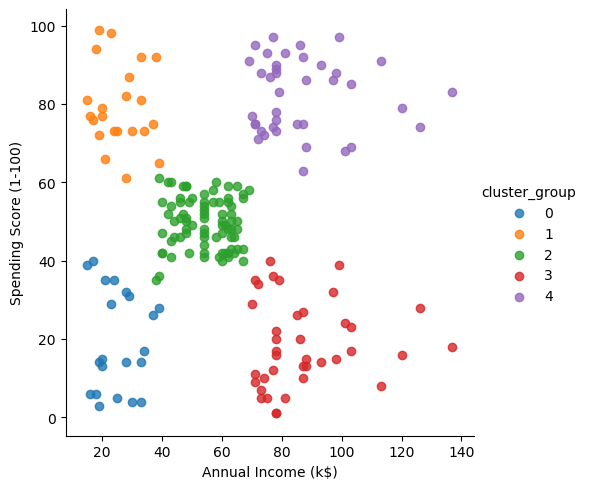

In [18]:
import seaborn as sns
facet = sns.lmplot(
    data=Supervised,
    x=Supervised.columns[3],
    y=Supervised.columns[4],
    hue=Supervised.columns[5],
    fit_reg=False,
    legend=True,
    legend_out=True
)